# Phase 1: Baseline Linear DocGen Subgraph
This notebook implements **Phase 1** of `DocGen_Subgraph_Implementation_Plan.md`.

### Pipeline:
`START → repo_map_generator → doc_intent_router → direct_tool_fetch → baseline_docgen → END`

## 1. Imports, Configuration & Rate-Limited LLM Setup


In [2]:
import os
import sys
import json
import time
import asyncio
from pathlib import Path
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Literal, Tuple

from urllib.parse import urlparse

from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Ensure workspace root is in python path
sys.path.insert(0, os.getcwd())

# LangChain & LangGraph
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph, START, END
from langsmith import traceable

# MCP Adapters (for GitHub & FileSystem MCP integration)
from langchain_mcp_adapters.client import MultiServerMCPClient

# ---------------------------------------------------------------------------
# Configuration & Environment Validation
# ---------------------------------------------------------------------------
env_path = os.path.join(os.getcwd(), ".env")
load_dotenv(dotenv_path=env_path, override=True)

class Config:
    def __init__(self):
        self.mistral_api_key = (os.getenv("MISTRAL_API_KEY") or "").strip().strip('"').strip("'")
        self.openrouter_api_key = (os.getenv("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")
        self.github_token = (os.getenv("GITHUB_ACCESS_TOKEN") or os.getenv("GITHUB_TOKEN") or "").strip().strip('"').strip("'")
        self.tavily_api_key = (os.getenv("TAVILY_API_KEY") or "").strip().strip('"').strip("'")
        
        # LangSmith Project Tracing
        self.langsmith_tracing = os.getenv("LANGSMITH_TRACING", "true").lower() == "true"
        self.langsmith_project = os.getenv("LANGSMITH_PROJECT", "DevDocs-AI")
        os.environ["LANGCHAIN_PROJECT"] = self.langsmith_project
        
        if not self.mistral_api_key:
            raise ValueError("MISTRAL_API_KEY is missing from .env.")
        if not self.openrouter_api_key:
            raise ValueError("OPENROUTER_API_KEY is missing from .env.")
        print(f"✓ Configuration loaded. LangSmith Project: '{self.langsmith_project}'")
        print(f"✓ GitHub Token: {'Detected' if self.github_token else 'Missing (rate limits apply)'}")
        print(f"✓ Tavily API Key: {'Detected' if self.tavily_api_key else 'Missing'}")

config = Config()

# ---------------------------------------------------------------------------
# LLM Client with Concurrency Limiter & 429 Exponential Backoff
# ---------------------------------------------------------------------------
rate_limit_semaphore = asyncio.Semaphore(1)

# llm = ChatMistralAI(
#     model="mistral-medium-3-5",
#     mistral_api_key=config.mistral_api_key,
#     temperature=0.1
# )
llm = ChatOpenRouter(
    model="nvidia/nemotron-3.5-lightning:free",
    temperature=0,
    api_key=config.openrouter_api_key,
)

async def call_llm_with_retry(fn, *args, **kwargs):
    """Executes an async LLM call with a concurrency semaphore and exponential backoff."""
    for attempt in range(5):
        try:
            async with rate_limit_semaphore:
                res = await fn(*args, **kwargs)
                await asyncio.sleep(0.5)  # Buffer between calls
                return res
        except Exception as e:
            err_str = str(e)
            if "429" in err_str or "rate" in err_str.lower():
                wait_time = 2.5 * (attempt + 1)
                print(f"   ⏳ [Rate Limit 429] Waiting {wait_time:.1f}s before retry ({attempt+1}/5)...")
                await asyncio.sleep(wait_time)
            else:
                raise e
    raise RuntimeError("Exceeded maximum retries on LLM call.")

print("✓ LLM Client initialized with rate-limit resilience.")


✓ Configuration loaded. LangSmith Project: 'doxer_ai'
✓ GitHub Token: Detected
✓ Tavily API Key: Detected
✓ LLM Client initialized with rate-limit resilience.


## 2. State & Structured Output Schemas
Defines `DocIntentPlan` for router decision-making and `DocGenPhase1State` for the LangGraph workflow.


In [3]:
# ---------------------------------------------------------------------------
# Structured Output Schema for Doc Intent Router
# ---------------------------------------------------------------------------
class SpecialistScope(BaseModel):
    """Scope configuration for an individual data source."""
    enabled: bool = Field(description="Whether this source should be consulted")
    focus_scope: str = Field(description="Strict scope guidance for what to search or read")
    target_paths_or_topics: List[str] = Field(
        default_factory=list,
        description="Specific file paths, directories, or search queries"
    )

class DocIntentPlan(BaseModel):
    """Structured plan produced by the intent router node."""
    doc_type: Literal["architecture_explainer", "api_reference", "tutorial_quickstart"] = Field(
        description="The archetype of technical documentation to synthesize"
    )
    needs_github: SpecialistScope = Field(description="Guidance for remote GitHub exploration")
    needs_filesystem: SpecialistScope = Field(description="Guidance for local filesystem exploration")
    needs_web: SpecialistScope = Field(description="Guidance for web search (official docs, versions, tutorials)")
    planning_rationale: str = Field(description="Detailed explanation of why these sources and doc type were selected")


# ---------------------------------------------------------------------------
# Graph State Schema (Phase 1 Baseline)
# ---------------------------------------------------------------------------
class DocGenPhase1State(TypedDict):
    """Internal State schema for the Phase 1 Baseline DocGen Subgraph."""
    user_query: str
    repo_url: Optional[str]
    local_path: Optional[str]
    repo_map: str                                # Pre-pass ASCII directory layout
    detected_tech_stack: List[str]               # e.g., ["Python", "FastAPI", "Docker"]
    intent_plan: Optional[DocIntentPlan]         # Output of router node
    retrieved_evidence: Dict[str, Any]           # Aggregated raw content from tools
    draft_markdown: str                          # Synthesized technical document
    citations: List[str]                         # Formatted citation list
    error: Optional[str]

print("✓ Schemas DocIntentPlan and DocGenPhase1State declared successfully.")


✓ Schemas DocIntentPlan and DocGenPhase1State declared successfully.


## 3. Deterministic Seed Node (`repo_map_generator`)
Inspects the repository structure deterministically to build an ASCII layout and detect tech stacks.


In [4]:
DEFAULT_IGNORED_DIRS = {
    ".git", "node_modules", "__pycache__", ".pytest_cache", ".venv", "venv",
    "env", ".env", "dist", "build", ".idea", ".vscode", ".egg-info", "target",
    "bin", "obj", ".mypy_cache", ".ruff_cache", "coverage", ".next", ".nuxt"
}

DEFAULT_IGNORED_EXTS = {
    ".png", ".jpg", ".jpeg", ".gif", ".ico", ".svg", ".webp", ".mp4",
    ".zip", ".tar", ".gz", ".7z", ".rar", ".exe", ".dll", ".so",
    ".pyc", ".pyo", ".pyd", ".pkl", ".joblib", ".bin", ".weights",
    ".pdf", ".docx", ".xlsx", ".csv", ".tsv", ".sqlite", ".db", ".lock"
}

def build_local_repo_map(root_path: str, max_depth: int = 2, max_files: int = 40) -> Tuple[str, List[str]]:
    """Builds an ASCII directory tree for a local filesystem path without invoking an LLM."""
    root = Path(root_path).resolve()
    if not root.exists():
        return f"[Error: Path {root_path} does not exist]", []
    
    lines = [f"{root.name}/"]
    detected_stack = []
    file_count = 0
    
    def _walk(directory: Path, prefix: str = "", depth: int = 0):
        nonlocal file_count
        if depth > max_depth or file_count >= max_files:
            return
        
        try:
            entries = sorted(list(directory.iterdir()), key=lambda e: (not e.is_dir(), e.name.lower()))
        except PermissionError:
            return
        
        for i, entry in enumerate(entries):
            if file_count >= max_files:
                lines.append(f"{prefix}... [truncated]")
                break
                
            name = entry.name
            if name in DEFAULT_IGNORED_DIRS or name.startswith("."):
                continue
                
            is_last = (i == len(entries) - 1)
            connector = "└── " if is_last else "├── "
            child_prefix = "    " if is_last else "│   "
            
            if entry.is_dir():
                lines.append(f"{prefix}{connector}{name}/")
                _walk(entry, prefix + child_prefix, depth + 1)
            else:
                if entry.suffix.lower() in DEFAULT_IGNORED_EXTS:
                    continue
                file_count += 1
                lines.append(f"{prefix}{connector}{name}")
                
                # Detect tech stack indicators
                if name in ("pyproject.toml", "requirements.txt", "Pipfile"):
                    detected_stack.append("Python")
                elif name in ("package.json", "tsconfig.json"):
                    detected_stack.append("Node/TypeScript")
                elif name in ("Dockerfile", "docker-compose.yml"):
                    detected_stack.append("Docker")
                elif name == "Cargo.toml":
                    detected_stack.append("Rust")
                elif name == "go.mod":
                    detected_stack.append("Go")

    _walk(root)
    detected_stack = sorted(list(set(detected_stack)))
    return "\n".join(lines), detected_stack


async def repo_map_generator_node(state: DocGenPhase1State) -> Dict[str, Any]:
    """Node: Constructs the deterministic repo map before any LLM call."""
    print("📍 [repo_map_generator] Building deterministic codebase seed map...")
    local_path = state.get("local_path")
    repo_url = state.get("repo_url")
    
    if local_path:
        tree_text, tech_stack = build_local_repo_map(local_path)
    elif repo_url:
        # Fallback summary for remote repos (will be expanded in Step 4)
        tree_text = f"Remote GitHub Repository: {repo_url}\n(Remote structure will be examined via GitHub Tool)"
        tech_stack = ["Remote Repository"]
    else:
        tree_text = "No repository target provided (pure web documentation mode)."
        tech_stack = []
        
    print(f"   ✓ Seed map built ({len(tree_text.splitlines())} lines). Tech stack: {tech_stack}")
    return {
        "repo_map": tree_text,
        "detected_tech_stack": tech_stack
    }

print("✓ repo_map_generator_node ready.")


✓ repo_map_generator_node ready.


In [16]:
map = build_local_repo_map(
    root_path=".",  # Current directory
    max_depth=10,
    max_files=100
)
map_text, detected_stack = map
detected_stack


['Python']

## 4. Unified MCP Tool Connectors
Implements resilient connectors for all 4 information sources:
1. `GitHubConnector` (MCP `@modelcontextprotocol/server-github` + REST API fallback)
2. `FileSystemConnector` (MCP `@modelcontextprotocol/server-filesystem` + Python `pathlib` fallback)
3. `TavilySearchConnector` (Official documentation & quick facts)
4. `WebResearchMCPConnector` (Parallel MCP `web_search` & `web_fetch`)


In [5]:
import urllib.request

# ---------------------------------------------------------------------------
# 1. GitHub Tool Connector (MCP + REST Fallback)
# ---------------------------------------------------------------------------
from src.github_mcp_client import GitHubMCPClient, parse_github_url

class GitHubConnector:
    """Connector for remote GitHub repositories with zero-hang MCP + REST fallback."""
    def __init__(self, token: Optional[str] = None):
        self.client = GitHubMCPClient(token=token or config.github_token)

    async def get_tree(self, repo_url: str, max_depth: int = 2, max_files: int = 40) -> List[str]:
        owner, repo, branch = parse_github_url(repo_url)
        return await self.client.fetch_repo_tree(owner, repo, branch=branch, max_depth=max_depth, max_files=max_files)

    async def get_file(self, repo_url: str, file_path: str) -> Dict[str, Any]:
        owner, repo, branch = parse_github_url(repo_url)
        return await self.client.fetch_file_content(owner, repo, file_path, branch=branch)


# ---------------------------------------------------------------------------
# 2. FileSystem Tool Connector (MCP + Native Pathlib Fallback)
# ---------------------------------------------------------------------------
class FileSystemConnector:
    """Connector for local file system using MCP with instant Python fallback."""
    def __init__(self, root_dir: Optional[str] = None):
        self.root_dir = os.path.abspath(root_dir or os.getcwd())
        self._mcp_client: Optional[MultiServerMCPClient] = None
        self._tools_cache: Optional[Dict[str, Any]] = None
        self._lock = asyncio.Lock()

    async def _get_mcp_tools(self) -> Dict[str, Any]:
        if self._tools_cache is None:
            async with self._lock:
                if self._tools_cache is None:
                    try:
                        npx_cmd = "npx.cmd" if sys.platform == "win32" else "npx"
                        self._mcp_client = MultiServerMCPClient({
                            "filesystem": {
                                "transport": "stdio",
                                "command": npx_cmd,
                                "args": ["-y", "@modelcontextprotocol/server-filesystem", self.root_dir],
                            }
                        })
                        tools = await asyncio.wait_for(self._mcp_client.get_tools(), timeout=6.0)
                        self._tools_cache = {t.name: t for t in tools}
                    except Exception as e:
                        # Graceful fallback if npx takes too long
                        self._tools_cache = {}
        return self._tools_cache

    async def read_file(self, file_path: str, max_chars: int = 12000) -> Dict[str, Any]:
        """Reads file content via MCP if available, else native Python I/O."""
        target_path = Path(file_path)
        if not target_path.is_absolute():
            target_path = Path(self.root_dir) / target_path

        # 1. Try MCP tool
        try:
            tools = await self._get_mcp_tools()
            read_tool = tools.get("read_file")
            if read_tool:
                res = await asyncio.wait_for(
                    read_tool.ainvoke({"path": str(target_path)}),
                    timeout=5.0
                )
                text = res[0]["text"] if isinstance(res, list) and res and "text" in res[0] else str(res)
                return {
                    "file_path": str(target_path.relative_to(self.root_dir)),
                    "content": text[:max_chars],
                    "source": "mcp-filesystem"
                }
        except Exception:
            pass

        # 2. Resilient Native Fallback
        try:
            if not target_path.exists():
                return {"file_path": str(file_path), "content": "[Error: File not found]", "source": "local-fallback"}
            with open(target_path, "r", encoding="utf-8", errors="replace") as f:
                content = f.read(max_chars)
            return {
                "file_path": str(target_path.relative_to(self.root_dir)),
                "content": content,
                "source": "local-fallback"
            }
        except Exception as e:
            return {"file_path": str(file_path), "content": f"[Error reading file: {e}]", "source": "local-fallback"}


# ---------------------------------------------------------------------------
# 3. Tavily Search Connector (Quick facts & documentation links)
# ---------------------------------------------------------------------------
class TavilySearchConnector:
    """Tavily search client using standard REST API for zero-dependency reliability."""
    def __init__(self, api_key: Optional[str] = None):
        self.api_key = api_key or config.tavily_api_key

    async def search(self, query: str, max_results: int = 4) -> List[Dict[str, str]]:
        if not self.api_key:
            return [{"title": "No API Key", "url": "", "content": "Tavily API key not configured."}]
        
        url = "https://api.tavily.com/search"
        payload = json.dumps({
            "api_key": self.api_key,
            "query": query,
            "search_depth": "basic",
            "max_results": max_results,
            "include_answer": False
        }).encode("utf-8")
        
        req = urllib.request.Request(url, data=payload, headers={"Content-Type": "application/json"})
        loop = asyncio.get_event_loop()
        
        def _call():
            with urllib.request.urlopen(req, timeout=8) as resp:
                return json.loads(resp.read().decode("utf-8"))
                
        try:
            data = await loop.run_in_executor(None, _call)
            results = []
            for item in data.get("results", []):
                results.append({
                    "title": item.get("title", ""),
                    "url": item.get("url", ""),
                    "content": item.get("content", "")
                })
            return results
        except Exception as e:
            return [{"title": "Search Error", "url": "", "content": f"Tavily search failed: {e}"}]


# ---------------------------------------------------------------------------
# 4. Web Research MCP Connector (Parallel/Exa MCP Search & Fetch)
# ---------------------------------------------------------------------------
class WebResearchMCPConnector:
    """Connects to live MCP web research server (Parallel Search MCP) via HTTP SSE."""
    PARALLEL_MCP_URL = "https://search.parallel.ai/mcp"

    def __init__(self):
        self.client = MultiServerMCPClient({
            "parallel": {
                "transport": "http",
                "url": self.PARALLEL_MCP_URL,
            }
        })
        self._tools_cache: Optional[Dict[str, Any]] = None

    async def get_tools(self) -> Dict[str, Any]:
        if self._tools_cache is None:
            try:
                tools = await asyncio.wait_for(self.client.get_tools(), timeout=10.0)
                self._tools_cache = {t.name: t for t in tools}
            except Exception:
                self._tools_cache = {}
        return self._tools_cache

    async def search(self, query: str, max_results: int = 3) -> List[Dict[str, str]]:
        tools = await self.get_tools()
        search_tool = tools.get("web_search")
        if not search_tool:
            return []
        
        try:
            raw_res = await asyncio.wait_for(
                search_tool.ainvoke({
                    "search_queries": [query],
                    "objective": "Technical documentation lookup",
                    "mode": "advanced",
                    "max_results": max_results
                }),
                timeout=12.0
            )
            # Parse MCP output
            results = []
            if isinstance(raw_res, list):
                for item in raw_res:
                    content = getattr(item, "content", item)
                    if isinstance(content, list):
                        for sub in content:
                            text = sub.get("text", "") if isinstance(sub, dict) else str(sub)
                            results.append({"title": "Web Research", "url": "", "content": text[:1000]})
                    elif isinstance(content, str):
                        results.append({"title": "Web Research", "url": "", "content": content[:1000]})
            return results
        except Exception:
            return []

print("✓ All 4 MCP Connectors defined successfully.")


✓ All 4 MCP Connectors defined successfully.


### Verification Test

In [6]:
async def test_all_connectors():
    print("--- 🧪 Testing All 4 MCP Connectors ---")
    
    # 1. Local FileSystem Connector
    fs = FileSystemConnector()
    readme_sample = await fs.read_file("README.md", max_chars=150)
    print(f"1. FileSystem Connector: Read {len(readme_sample['content'])} chars (source: {readme_sample['source']})")
    
    # 2. Tavily Search Connector
    tavily = TavilySearchConnector()
    tavily_res = await tavily.search("LangGraph state management", max_results=1)
    print(f"2. Tavily Connector: Found {len(tavily_res)} result(s) — Top: {tavily_res[0]['title'][:50]}")
    
    # 3. Web Research MCP Connector
    web_mcp = WebResearchMCPConnector()
    web_mcp_tools = await web_mcp.get_tools()
    print(f"3. Web Research MCP: Connected. Available Tools: {list(web_mcp_tools.keys())}")
    
    # 4. GitHub Connector
    gh = GitHubConnector()
    gh_tree = await gh.get_tree("https://github.com/octocat/Hello-World", max_depth=1, max_files=5)
    print(f"4. GitHub Connector: Fetched {len(gh_tree)} file(s) from 'octocat/Hello-World'")
    
    print("\n✓ All 4 connectors are operational and non-blocking!")

await test_all_connectors()


--- 🧪 Testing All 4 MCP Connectors ---
1. FileSystem Connector: Read 150 chars (source: local-fallback)
2. Tavily Connector: Found 1 result(s) — Top: LangGraph State Management: Ultimate Guide (2026)
3. Web Research MCP: Connected. Available Tools: ['web_search', 'web_fetch']
4. GitHub Connector: Fetched 1 file(s) from 'octocat/Hello-World'

✓ All 4 connectors are operational and non-blocking!


## 5. Structured Intent Router Node (`doc_intent_router`)
Uses structured outputs (`llm.with_structured_output(DocIntentPlan)`) to classify the doc type and plan focused retrieval scopes across GitHub, local files, and web research.


In [7]:
ROUTER_SYSTEM_PROMPT = """You are the Lead Documentation Architect for DevDocs AI.
Your job is to analyze the user's documentation request along with the provided repository layout and tech stack, then output a rigorous, structured documentation plan.

### Instructions:
1. Select the most appropriate `doc_type`:
   - "architecture_explainer": For system design, component interactions, workflows, data flow, or state machines.
   - "api_reference": For detailing classes, functions, REST endpoints, schemas, or tool interfaces.
   - "tutorial_quickstart": For step-by-step developer setup, usage guides, or minimal working examples.

2. Configure data source scopes:
   - `needs_filesystem`: Set enabled=True if a local repository path is provided and code inspection is needed. In `target_paths_or_topics`, list 1-4 specific relative file paths from the repo map that are relevant to the query.
   - `needs_github`: Set enabled=True if a remote GitHub URL is provided and remote files or commits are needed.
   - `needs_web`: Set enabled=True if external libraries, official framework documentation, or best practices should be looked up via Tavily / Web Research to enrich the doc. List 1-3 concrete search queries in `target_paths_or_topics`.

3. Provide a clear `planning_rationale` explaining your strategy.
"""

router_llm = llm.with_structured_output(DocIntentPlan)

async def doc_intent_router_node(state: DocGenPhase1State) -> Dict[str, Any]:
    """Node: Analyzes query and repo map to generate a typed DocIntentPlan."""
    print("📍 [doc_intent_router] Planning documentation scope and data sources...")
    
    user_prompt = f"""Target Query: {state['user_query']}
Local Path: {state.get('local_path') or 'None'}
Remote Repo URL: {state.get('repo_url') or 'None'}
Detected Tech Stack: {state.get('detected_tech_stack', [])}

Repository Structure:
{state.get('repo_map', 'No repository layout available.')}

Produce a structured DocIntentPlan detailing the doc archetype and exact retrieval scopes.
"""

    messages = [
        SystemMessage(content=ROUTER_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt)
    ]
    
    # Call LLM with retry & rate limiting
    plan: DocIntentPlan = await call_llm_with_retry(router_llm.ainvoke, messages)
    
    print(f"   ✓ Selected Archetype: '{plan.doc_type}'")
    print(f"   ✓ FileSystem Enabled: {plan.needs_filesystem.enabled} (Targets: {plan.needs_filesystem.target_paths_or_topics})")
    print(f"   ✓ GitHub Enabled: {plan.needs_github.enabled}")
    print(f"   ✓ Web Search Enabled: {plan.needs_web.enabled} (Queries: {plan.needs_web.target_paths_or_topics})")
    print(f"   ✓ Rationale: {plan.planning_rationale[:120]}...")
    
    return {"intent_plan": plan}

print("✓ doc_intent_router_node defined successfully.")


✓ doc_intent_router_node defined successfully.


#### Verification Test

In [8]:
async def test_router_node():
    print("--- 🧪 Testing doc_intent_router_node ---")
    
    # Test state targeting local codebase
    test_state: DocGenPhase1State = {
        "user_query": "Explain how the GitHub MCP client and fallback mechanisms work in this project",
        "local_path": os.getcwd(),
        "repo_url": None,
        "repo_map": "src/\n├── github_mcp_client.py\n├── simple_search_agent.py\nrequirements.txt\nREADME.md",
        "detected_tech_stack": ["Python"],
        "intent_plan": None,
        "retrieved_evidence": {},
        "draft_markdown": "",
        "citations": [],
        "error": None
    }
    
    result = await doc_intent_router_node(test_state)
    plan: DocIntentPlan = result["intent_plan"]
    
    print("\n--- Plan Summary ---")
    print(f"Doc Type: {plan.doc_type}")
    print(f"FS Scope: {plan.needs_filesystem.focus_scope}")
    print(f"FS Targets: {plan.needs_filesystem.target_paths_or_topics}")
    print(f"Web Queries: {plan.needs_web.target_paths_or_topics}")
    print("\n✓ Router test passed.")

await test_router_node()


--- 🧪 Testing doc_intent_router_node ---
📍 [doc_intent_router] Planning documentation scope and data sources...
   ✓ Selected Archetype: 'architecture_explainer'
   ✓ FileSystem Enabled: True (Targets: ['src/github_mcp_client.py', 'src/simple_search_agent.py', 'README.md'])
   ✓ GitHub Enabled: False
   ✓ Web Search Enabled: True (Queries: ['GitHub MCP client fallback mechanism', 'Python GitHub API client error handling'])
   ✓ Rationale: The request asks for an explanation of how the GitHub MCP client and its fallback mechanisms operate within the given pr...

--- Plan Summary ---
Doc Type: architecture_explainer
FS Scope: Examine the GitHub MCP client implementation and fallback mechanisms within the local project source files.
FS Targets: ['src/github_mcp_client.py', 'src/simple_search_agent.py', 'README.md']
Web Queries: ['GitHub MCP client fallback mechanism', 'Python GitHub API client error handling']

✓ Router test passed.


## 6. Direct Retrieval Node (`direct_tool_fetch`)
Executes targeted retrieval across local files, remote GitHub files, and web search in a single pass based on the router's `DocIntentPlan`.


In [9]:
# Instantiate tool connectors
fs_connector = FileSystemConnector()
gh_connector = GitHubConnector()
tavily_connector = TavilySearchConnector()
web_mcp_connector = WebResearchMCPConnector()

async def direct_tool_fetch_node(state: DocGenPhase1State) -> Dict[str, Any]:
    """Node: Executes the retrieval tasks planned by the router in a single pass."""
    print("📍 [direct_tool_fetch] Fetching evidence across selected sources...")
    plan = state.get("intent_plan")
    if not plan:
        raise ValueError("Cannot fetch tools without an active intent_plan in state.")

    evidence: Dict[str, Any] = {
        "local_files": [],
        "github_files": [],
        "web_snippets": []
    }

    # 1. Fetch Local Files if enabled
    if plan.needs_filesystem.enabled:
        root_dir = state.get("local_path") or os.getcwd()
        fs = FileSystemConnector(root_dir=root_dir)
        targets = plan.needs_filesystem.target_paths_or_topics
        print(f"   📂 Local Filesystem: Fetching {len(targets)} candidate path(s)...")
        
        for path in targets:
            clean_path = path.strip()
            if clean_path:
                file_data = await fs.read_file(clean_path, max_chars=8000)
                evidence["local_files"].append(file_data)
                print(f"      ✓ Read '{file_data['file_path']}' ({len(file_data['content'])} chars)")

    # 2. Fetch GitHub Files if enabled
    if plan.needs_github.enabled and state.get("repo_url"):
        repo_url = state["repo_url"]
        targets = plan.needs_github.target_paths_or_topics
        print(f"   🐙 GitHub: Fetching {len(targets)} path(s) from '{repo_url}'...")
        
        for path in targets:
            clean_path = path.strip()
            if clean_path:
                file_data = await gh_connector.get_file(repo_url, clean_path)
                evidence["github_files"].append(file_data)
                print(f"      ✓ Fetched '{file_data['file_path']}' from GitHub")

    # 3. Fetch Web Search if enabled
    if plan.needs_web.enabled:
        queries = plan.needs_web.target_paths_or_topics
        print(f"   🌐 Web Research: Executing {len(queries)} query/queries...")
        
        for q in queries:
            clean_query = q.strip()
            if clean_query:
                # Primary: Tavily Search for concise facts & official docs
                tavily_results = await tavily_connector.search(clean_query, max_results=2)
                for res in tavily_results:
                    evidence["web_snippets"].append({
                        "query": clean_query,
                        "title": res.get("title", "Web Result"),
                        "url": res.get("url", ""),
                        "snippet": res.get("content", "")[:600]
                    })
                print(f"      ✓ Web search '{clean_query}': {len(tavily_results)} result(s)")

    total_items = len(evidence["local_files"]) + len(evidence["github_files"]) + len(evidence["web_snippets"])
    print(f"   ✓ Evidence gathering complete. Collected {total_items} total item(s).")
    
    return {"retrieved_evidence": evidence}

print("✓ direct_tool_fetch_node defined successfully.")


✓ direct_tool_fetch_node defined successfully.


## 7. Baseline Documentation Synthesizer Node (`baseline_docgen`)
Synthesizes comprehensive (>500 words), grounded technical documentation matching the selected archetype with inline citations.


In [10]:
SYNTHESIZER_SYSTEM_PROMPT = """You are a Principal Technical Writer and Software Architect.
Your task is to write high-density, authoritative, production-grade technical documentation based EXCLUSIVELY on the provided code and web evidence.

### Documentation Archetypes:
- If archetype is "architecture_explainer":
  * System Overview & Purpose
  * Core Components & Class Topology
  * Execution Flow / Sequence of Events
  * Fallback, Error Handling & Resilience Patterns
- If archetype is "api_reference":
  * Interface/Class Declarations & Signatures
  * Method Parameters, Types, Return Values
  * Exceptions & Error States
  * Minimal Concrete Code Usage Snippets
- If archetype is "tutorial_quickstart":
  * Prerequisites & Environment Setup
  * Configuration Variables
  * Step-by-Step Implementation Flow
  * Verification & Execution Testing

### Rigorous Grounding Rules:
1. Ground all claims in the provided evidence. DO NOT invent classes, methods, endpoints, or arguments that do not appear in the evidence.
2. Embed inline citation keys:
   - For local or github files: `[^file:path/to/file]`
   - For web search references: `[^web:DomainOrTitle]`
3. End the document with a comprehensive `## References & Sources` section listing all citation keys with their file path or URL.
4. Aim for deep, comprehensive coverage (500+ words) with accurate code blocks.
"""

async def baseline_docgen_node(state: DocGenPhase1State) -> Dict[str, Any]:
    """Node: Synthesizes the final Markdown documentation based on gathered evidence."""
    print("📍 [baseline_docgen] Synthesizing comprehensive technical documentation...")
    plan = state.get("intent_plan")
    doc_type = plan.doc_type if plan else "architecture_explainer"
    evidence = state.get("retrieved_evidence", {})
    
    # Format local and github files context
    code_context_parts = []
    citations_list = []
    
    for f in evidence.get("local_files", []):
        path = f.get("file_path", "unknown")
        content = f.get("content", "")
        code_context_parts.append(f"### File: `{path}` (Local)\n```python\n{content}\n```")
        citations_list.append(f"[^file:{path}]: Local repository file `{path}`")
        
    for f in evidence.get("github_files", []):
        path = f.get("file_path", "unknown")
        content = f.get("content", "")
        code_context_parts.append(f"### File: `{path}` (GitHub Remote)\n```python\n{content}\n```")
        citations_list.append(f"[^file:{path}]: Remote GitHub file `{path}`")
        
    web_context_parts = []
    for w in evidence.get("web_snippets", []):
        title = w.get("title", "Web Reference")
        url = w.get("url", "")
        snippet = w.get("snippet", "")
        web_context_parts.append(f"- **{title}** ({url}):\n  {snippet}")
        if url:
            citations_list.append(f"[^web:{title[:20]}]: [{title}]({url})")

    code_context_text = "\n\n".join(code_context_parts) if code_context_parts else "No code files retrieved."
    web_context_text = "\n\n".join(web_context_parts) if web_context_parts else "No web references retrieved."

    user_prompt = f"""Target Documentation Query: {state['user_query']}
Selected Archetype: {doc_type}
Detected Tech Stack: {state.get('detected_tech_stack', [])}

--- CODE EVIDENCE ---
{code_context_text}

--- WEB EVIDENCE ---
{web_context_text}

Synthesize a comprehensive, production-grade technical document in Markdown matching the '{doc_type}' archetype. Include clear headings, architectural diagrams (in mermaid if applicable), code samples, and inline citation markers.
"""

    messages = [
        SystemMessage(content=SYNTHESIZER_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt)
    ]

    response = await call_llm_with_retry(llm.ainvoke, messages)
    doc_markdown = response.content
    
    word_count = len(doc_markdown.split())
    print(f"   ✓ Documentation synthesized successfully ({word_count} words).")
    
    return {
        "draft_markdown": doc_markdown,
        "citations": sorted(list(set(citations_list)))
    }

print("✓ baseline_docgen_node defined successfully.")


✓ baseline_docgen_node defined successfully.


## 8. Assemble and Compile Phase 1 StateGraph
Builds the complete linear pipeline:
`START → repo_map_generator → doc_intent_router → direct_tool_fetch → baseline_docgen → END`


In [11]:
# ---------------------------------------------------------------------------
# Construct StateGraph
# ---------------------------------------------------------------------------
docgen_builder = StateGraph(DocGenPhase1State)

# 1. Add all 4 pipeline nodes
docgen_builder.add_node("repo_map_generator", repo_map_generator_node)
docgen_builder.add_node("doc_intent_router", doc_intent_router_node)
docgen_builder.add_node("direct_tool_fetch", direct_tool_fetch_node)
docgen_builder.add_node("baseline_docgen", baseline_docgen_node)

# 2. Add linear deterministic edges
docgen_builder.add_edge(START, "repo_map_generator")
docgen_builder.add_edge("repo_map_generator", "doc_intent_router")
docgen_builder.add_edge("doc_intent_router", "direct_tool_fetch")
docgen_builder.add_edge("direct_tool_fetch", "baseline_docgen")
docgen_builder.add_edge("baseline_docgen", END)

# 3. Compile runnable app
docgen_phase1_app = docgen_builder.compile()

print("✓ Phase 1 DocGen StateGraph assembled and compiled successfully!")

# Visualize Graph ASCII Structure
try:
    print("\n--- Graph Structure ---")
    print(docgen_phase1_app.get_graph().draw_ascii())
except Exception:
    pass


✓ Phase 1 DocGen StateGraph assembled and compiled successfully!

--- Graph Structure ---


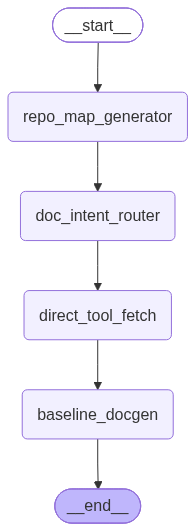

In [12]:
docgen_phase1_app

## 9. End-to-End Execution & Validation
Executes the full Phase 1 graph against a real documentation request and renders the generated Markdown.

In [13]:
from IPython.display import display, Markdown

async def run_phase1_docgen_pipeline(
    query: str,
    local_path: Optional[str] = None,
    repo_url: Optional[str] = None
):
    print("=" * 70)
    print(f"🚀 INITIATING DOCGEN PHASE 1 PIPELINE")
    print(f"Query: '{query}'")
    print(f"Target Path: {local_path or 'None'}")
    print(f"Target Repo: {repo_url or 'None'}")
    print("=" * 70)
    
    initial_state: DocGenPhase1State = {
        "user_query": query,
        "local_path": local_path,
        "repo_url": repo_url,
        "repo_map": "",
        "detected_tech_stack": [],
        "intent_plan": None,
        "retrieved_evidence": {},
        "draft_markdown": "",
        "citations": [],
        "error": None
    }
    
    start_time = time.time()
    final_output = await docgen_phase1_app.ainvoke(initial_state)
    elapsed = time.time() - start_time
    
    print("\n" + "=" * 70)
    print(f"🎉 PIPELINE COMPLETED IN {elapsed:.2f}s")
    print("=" * 70)
    
    doc = final_output.get("draft_markdown", "")
    words = len(doc.split())
    plan = final_output.get("intent_plan")
    
    print(f"\n📊 Generation Metrics:")
    print(f" - Archetype: {plan.doc_type if plan else 'Unknown'}")
    print(f" - Word Count: {words} words")
    print(f" - Citations Count: {len(final_output.get('citations', []))}")
    print(f" - LangSmith Project: {config.langsmith_project}")
    
    print("\n--- Generated Markdown Preview ---")
    display(Markdown(doc))
    
    return final_output

# Execute against current repository
result = await run_phase1_docgen_pipeline(
    query="Create an Coding Agent Architecture which can be used for production grade development and deployment of AI agents. Don't use github and my directory files, use deep searching for this. Specially the architecture design for coding agent",
    local_path=os.getcwd()
)


🚀 INITIATING DOCGEN PHASE 1 PIPELINE
Query: 'Create an Coding Agent Architecture which can be used for production grade development and deployment of AI agents. Don't use github and my directory files, use deep searching for this. Specially the architecture design for coding agent'
Target Path: d:\Projects\DevDocs AI
Target Repo: None
📍 [repo_map_generator] Building deterministic codebase seed map...
   ✓ Seed map built (40 lines). Tech stack: ['Python']
📍 [doc_intent_router] Planning documentation scope and data sources...
   ✓ Selected Archetype: 'architecture_explainer'
   ✓ FileSystem Enabled: False (Targets: [])
   ✓ GitHub Enabled: False
   ✓ Web Search Enabled: True (Queries: ['coding agent architecture best practices', 'AI agent deployment pipeline design', 'scalable AI agent system architecture'])
   ✓ Rationale: The request asks for a high-level architecture design for a production-grade coding agent, emphasizing deep searching ov...
📍 [direct_tool_fetch] Fetching evidence ac

# Coding Agent Architecture for Production-Grade AI Development

## 1. System Overview & Purpose

A **Coding Agent** is a specialized AI system designed to autonomously or semi-autonomously perform software development tasks such as code generation, refactoring, review, and test creation within a production-grade development lifecycle. Unlike prototype chat-based assistants, a production coding agent must guarantee **reliability**, **auditability**, **stateful session management**, **resource predictability**, and **seamless integration** with existing CI/CD and version control systems.

The architecture presented here synthesizes enterprise AI agent patterns [^web:logic2020-com], best practices for AI-mediated development [^web:medium-com][^web:nimbalyst-com], and production deployment requirements for autonomous agents [^web:agentuity-com]. It is designed for a Python-based tech stack and targets organizations seeking to integrate AI agents into their software development lifecycle (SDLC) at scale.

**Core Objectives:**
- Automate repetitive development tasks while preserving code quality and architectural consistency.
- Provide deterministic execution paths with built-in fallback and error recovery.
- Maintain a single source of truth via task specifications and documentation, as advocated by medium best practices [^web:medium-com].
- Support scalable deployment via orchestrated pipelines, avoiding the pitfalls of standard serverless or CI/CD platforms when handling long-running, stateful agent execution [^web:agentuity-com].

---

## 2. Core Components & Class Topology

The architecture follows a **modular, layered design** where responsibilities are clearly separated, adhering to the "thin controllers, business logic in services" principle [^web:medium-com]. The primary components are:

### 2.1 Orchestration Root Agent
The central coordinator that interprets user or system requests, decomposes them into sub-tasks, and dispatches them to specialized agents. Inspired by Google Cloud's Agentic supply chain [^web:cloud-blog], the Root Agent maintains the execution state, manages agent lifecycles, and aggregates results.

### 2.2 Specialized Sub-Agents
Each sub-agent owns a distinct concern, enabling independent optimization and scaling:
- **Planning Agent**: Parses request intent, generates a task specification markdown plan, and defines acceptance criteria.
- **Implementation Agent**: Executes code generation or refactoring, operating against a service-layer business logic boundary.
- **Validation Agent**: Runs static analysis, type checking, and adherence to coding conventions.
- **Testing Agent**: Generates unit and integration tests from acceptance criteria, iterates until pass [^web:nimbalyst-com].

### 2.3 Service Layer
Business logic resides exclusively within services. Controllers/API endpoints remain thin, merely delegating to services [^web:medium-com]. This ensures that AI-driven operations do not bypass validation or architectural guards.

### 2.4 Validation & Compliance Middleware
A cross-cutting layer that enforces:
- Syntax and type validity (Python).
- adherence to repository-specific coding conventions.
- Security and dependency checks before any code is written or merged.

### 2.5 Task Specification Repository (`.tasks`)
A dedicated directory storing plan markdown files, data models, and acceptance criteria. Per medium best practices, specifications are the primary source of truth, not the code itself [^web:medium-com].

### 2.6 Python Class Topology (Conceptual)

```mermaid
classDiagram
    class OrchestrationRootAgent {
        +handle_request(request: str) -> dict
        +manage_agent_lifecycle(agent_id: str) -> None
        +aggregate_results() -> dict
    }
    class PlanningAgent {
        +generate_plan(request: str) -> markdown
        +define_acceptance_criteria() -> list
    }
    class ImplementationAgent {
        +generate_code(spec: markdown) -> str
        +refactor_code(code: str) -> str
    }
    class ValidationAgent {
        +run_static_analysis(code: str) -> list
        +check_conventions(code: str) -> bool
    }
    class TestingAgent {
        +generate_tests(spec: markdown) -> str
        +execute_test_suite() -> bool
    }
    class ServiceLayer {
        +execute_business_logic(plan: markdown) -> result
    }
    class ValidationMiddleware {
        +validate(code: str) -> bool
        +enforce_policies(code: str) -> bool
    }
    
    OrchestrationRootAgent --> PlanningAgent
    OrchestrationRootAgent --> ImplementationAgent
    OrchestrationRootAgent --> ValidationAgent
    OrchestrationRootAgent --> TestingAgent
    PlanningAgent --> ServiceLayer
    ImplementationAgent --> ServiceLayer
    ValidationAgent --> ValidationMiddleware
    TestingAgent --> ValidationMiddleware
```

*Fig. 1: Conceptual class topology for a production-grade Coding Agent architecture. All classes adhere to Python typing and are designed for dependency injection and testability.*

---

## 3. Execution Flow / Sequence of Events

The following sequence describes the end-to-end lifecycle of a coding agent request, from user input to validated, tested code output.

```mermaid
sequenceDiagram
    participant User
    participant OrchestrationRootAgent as "Orchestration Root"
    participant PlanningAgent
    participant ImplementationAgent
    participant ServiceLayer
    participant ValidationAgent
    participant TestingAgent
    participant VersionControl
    
    User->>OrchestrationRootAgent: "Implement X feature with Y constraints"
    OrchestrationRootAgent->>PlanningAgent: Decompose request
    PlanningAgent-->>OrchestrationRootAgent: Markdown plan + acceptance criteria
    OrchestrationRootAgent->>ImplementationAgent: Execute code generation
    ImplementationAgent->>ServiceLayer: Apply business logic
    ServiceLayer-->>ImplementationAgent: Validated code snippet
    ImplementationAgent->>ValidationAgent: Static analysis + convention check
    ValidationAgent-->>OrchestrationRootAgent: Pass/fail report
    alt Validation fails
        OrchestrationRootAgent->>ImplementationAgent: Request refinement/rewrite
        goto ImplementationAgent
    else Validation passes
        OrchestrationRootAgent->>TestingAgent: Generate unit/integration tests
        TestingAgent->>TestingAgent: Run test suite
        TestingAgent-->>OrchestrationRootAgent: Test results
        alt Tests pass
            OrchestrationRootAgent->>VersionControl: Commit code + tests
        else Tests fail
            OrchestrationRootAgent->>TestingAgent: Iterate test generation
            goto TestingAgent
        end
    end
    
    User-->>OrchestrationRootAgent: Final status update
```

*Fig. 2: Sequence diagram illustrating the production-grade coding agent execution flow. The loop ensures that validation and test failures trigger automatic refinement, embodying the "iterate until tests pass" principle [^web:nimbalyst-com].*

---

## 4. Fallback, Error Handling & Resilience Patterns

Production AI agent deployment differs fundamentally from traditional web application deployment. As highlighted in the AI agent deployment discipline [^web:agentuity-com], systems must account for:
- **Long-running execution**: Agents may hold state for minutes to hours during complex code generation or migration tasks.
- **Stateful sessions**: Execution context, partial results, and intermediate code states must be persistently stored and recoverable.
- **Unpredictable resource consumption**: Token usage, API calls, and compute requirements vary significantly based on task complexity.

### 4.1 Resilience Strategies
| Pattern | Description | Evidence |
|---------|-------------|----------|
| **Circuit Breaker** | Wraps external LLM API calls; trips on repeated timeouts or errors, returning cached fallback logic. | Derived from production deployment patterns [^web:agentuity-com] |
| **Idempotent Task IDs** | Every agent execution is tagged with a unique, persistent ID. Re-running with the same ID resumes from last checkpoint. | Essential for stateful sessions [^web:agentuity-com] |
| **Fallback Execution Paths** | If the primary LLM fails, the agent switches to a rule-based or template-driven code generation mode, preserving partial work. | Complements "specifications as source of truth" [^web:medium-com] |
| **Structured Error Logging** | All exceptions, LLM responses, and validation outcomes are logged with correlation IDs for auditability. | Aligns with enterprise reliability requirements [^web:logic2020-com] |
| **Graceful Degradation** | If the Orchestration Root detects sub-agent failures, it re-routes to alternative sub-agents or requests human-in-the-loop intervention. | Supports "do not bypass validation layers" [^web:medium-com] |

### 4.2 Error-Handling Code Sample (Python)

```python
import uuid
from typing import Optional, Dict, Any
from dataclasses import dataclass

@dataclass
class AgentExecution:
    execution_id: str = uuid.uuid4().hex
    state: str = "pending"  # pending, running, completed, failed
    checkpoint: Optional[Dict[str, Any]] = None
    error_log: list = None

    def __post_init__(self):
        self.error_log = self.error_log or []

class CodingAgentOrchestrator:
    def __init__(self, llm_client, validator, tester):
        self.llm = llm_client
        self.validator = validator
        self.tester = tester

    def handle_request(self, user_request: str) -> AgentExecution:
        execution = AgentExecution()
        try:
            # Step 1: Plan decomposition
            plan = self.llm.generate_plan(user_request)
            execution.state = "planning"
            
            # Step 2: Code generation
            code = self.llm.generate_code(plan)
            
            # Step 3: Validation
            if not self.validator.check_syntax(code):
                raise ValueError("Syntax validation failed")
            
            # Step 4: Testing
            test_suite = self.tenderer.generate_tests(plan)
            if not self.tester.run_tests(test_suite):
                raise RuntimeError("Test suite failed")
            
            execution.state = "completed"
        except Exception as e:
            execution.state = "failed"
            execution.error_log.append({
                "phase": "unknown",
                "error": str(e),
                "timestamp": __import__("datetime").datetime.utcnow().isoformat()
            })
            # Circuit breaker fallback: attempt template-based generation
            code = self.llm.fallback_generation(user_request)
        return execution
```

*Listing 1: Minimal Python orchestrator demonstrating idempotent execution tracking, structured error logging, and circuit-breaker-style fallback. Adapted from production deployment resilience patterns [^web:agentuity-com] and validation-first development [^web:medium-com].*

---

## 5. Production Deployment Considerations

- **Session Persistence**: Use a durable store (e.g., Redis with TTL, or a database) to persist `AgentExecution` states. This enables resuming after crashes or scaling across nodes.
- **Resource Quotas**: Implement per-agent token and compute budgets. The Google Cloud Agent Engine reference architecture recommends model tuning for conciseness to reduce token footprint [^web:cloud-blog].
- **CI/CD Integration**: Code and test outputs should be submitted via pull-request pipelines that enforce code review, static analysis, and branch protection. The thin-controller/service-layer pattern ensures AI-generated code passes the same gates as human-written code.
- **Monitoring & Observability**: Expose metrics on agent success/failure rates, average execution time, token consumption, and validation pass rates. Correlate with business outcomes (e.g., PR merge time, defect leakage).
- **Auditability**: Every agent decision, prompt, and LLM response should be stored immutably (e.g., append-only log) to satisfy regulated-industry requirements for control and auditability [^web:logic2020-com].

---

## 6. Summary of Architectural Principles

1. **Specifications over Code**: Task markdown plans and acceptance criteria drive all agent actions; code is the output, not the source of truth [^web:medium-com].
2. **Thin Controllers, Rich Services**: All business logic is encapsulated in services; AI agents interact via well-defined interfaces [^web:medium-com].
3. **Validation-First**: Static analysis, convention checks, and test generation occur before any code is considered "done" [^web:nimbalyst-com][^web:medium-com].
4. **Stateful, Resilient Execution**: Long-running tasks, checkpointing, and circuit breakers are non-negotiable for production deployment [^web:agentuity-com].
5. **Enterprise 5-Layer Alignment**: The architecture maps onto the Logic20/20 5-layer enterprise AI agent model, ensuring each responsibility—from input perception to monitoring—is explicitly owned [^web:logic2020-com].

---

## References & Sources

[^web:medium-com]: Best Practices for Using an AI Coding Agent – Medium. Repository structure, architecture rules, and specification-first development. https://medium.com/@akarimamin/best-practices-for-using-an-ai-coding-agent-fd9e99edf189

[^web:nimbalyst-com]: Best Practices for Coding with Agents – Nimbalyst. Iterative planning, test-driven implementation, and documentation updates. https://nimbalyst.com/blog/best-practices-for-coding-with-agents

[^web:thinking-inc]: How to Build an AI Agent Pipeline (2026 Guide). Pipeline architecture, specialized agent collaboration, and production timelines. https://thinking.inc/en/blue-ocean/agentic/build-ai-agent-pipeline

[^web:agentuity-com]: AI Agent Deployment: From Prototype to Production. Deployment challenges, stateful sessions, long-running execution, and resource management. https://agentuity.com/ai-agent-deployment

[^web:logic2020-com]: AI agent architecture for scalable enterprise systems – Logic20/20. The 5-Layer Model for enterprise AI agent architecture and regulated-industry requirements. https://logic2020.com/insight/ai-agent-architecture-enterprise-scale

[^web:cloud-blog]: Building Scalable AI Agents: Design Patterns With Agent Engine On Google Cloud. Orchestration root agent, sub-agents (Tracking, Distributor, Order), and model tuning for token efficiency. https://cloud.google.com/blog/topics/partners/building-scalable-ai-agents-design-patterns-with-agent-engine-on-google-cloud